In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1005. Miscellaneous Analyses/P1005.8. Wildfire As Review/Output'
cur_date = '062326'

library(readxl)
library(tidyverse)
library(fastDummies)
library(stringr)
library(reshape2)
library(ggnewscale)
library(patchwork)

# reading in files
heatmap_data = read_csv("Input/Heatmap.csv")
water_info_df = data.frame(read_excel("Input/Extraction Table.xlsx"))#[,c(1,2,4,8,9,11,12)]

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Rows: 22 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): Title, Citation, Location
dbl (10): Study_ID, Impacted_by_Soil, Impacted_by_Vegetation, Impacted_by_As...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet th

In [2]:
full_df = inner_join(heatmap_data[,c(1:4,12,13,9,10)], water_info_df[,c(1,2,9,12)])
head(full_df)

Joining with `by = join_by(Title, Citation)`


Study_ID,Title,Citation,Location,Impacts_Surface_Water,Impacts_Groundwater,Impacted_by_Built_Environment,Impacted_by_Land_Use,Primary_Mobilization_Pathway,Directionality
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,"(Murphy et al., 2020)",Colorado,1,0,0,1,Runoff,Increase
2,Feeding inhibition following in-situ and laboratory exposure as an indicator of ecotoxic impacts of wildfires in affected waterbodies,"(Ré et al., 2020)",Portugal,1,0,0,0,Runoff,Increase
3,"Paleolimnological Assessment of Wildfire-Derived Atmospheric Deposition of Trace Metal(loid)s and Major Ions to Subarctic Lakes (Northwest Territories, Canada)","(Pelletier et al., 2020)",Canada,1,0,0,0,Deposition,Increase
4,Assessment of superficial water quality of small catchment basins affected by Portuguese rural fires of 2017,"(Sequeira et al., 2020)",Portugal,1,0,0,0,Runoff,Increase
5,"Trace elements in stormflow, ash, and burned soil following the 2009 Station Fire in southern California","(Burton et al., 2016)",California,1,0,0,0,Runoff,Increase
6,The Rural Fires of 2017 and Their Influences on Water Quality: An Assessment of Causes and Effects,"(Sequeira et al., 2023)",Portugal,1,0,0,0,Runoff,Increase


Words about what the heatmap is showing.


In [3]:
heatmap_df = full_df %>%
    unite("location_citation", c("Location", "Citation"), sep = " ") %>%
    # creating new cols based on the classes in each of these cols
    dummy_cols( select_columns = "Primary_Mobilization_Pathway",
          remove_first_dummy = FALSE, remove_selected_columns = TRUE) %>%
    # cleaning up col names
    rename_with(~ str_remove(.x, "Primary_Mobilization_Pathway_")) %>%
    pivot_longer(cols = c(4:7,9:14), names_to = "Variable", values_to = "Value") %>%
    mutate(Value = ifelse(Value == 1, 'Yes', 'No')) %>%
    # cleaning up variable names
    mutate(Variable = str_replace_all(Variable, "_", " "),
          Variable = str_replace_all(Variable, "Arsenic", "As"),
          location_citation = str_replace_all(location_citation, ",", ""))

heatmap_df$Value = factor(heatmap_df$Value, levels = c('Yes', 'No'))

head(heatmap_df)

Study_ID,Title,location_citation,Directionality,Variable,Value
<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacts Surface Water,Yes
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacts Groundwater,No
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacted by Built Environment,No
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacted by Land Use,Yes
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Deposition,No
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Leaching,No


In [4]:
# creating annotation dfs
annotation_df <- unique(heatmap_df[, c("location_citation", "Directionality")])

# creating a df that leaves space b/w the annotation rows and the rest of the heatmap
spacer_df <- annotation_df
spacer_df$Variable <- "Spacer"
spacer_df$Directionality <- NA

annotation_df$Variable <- "Direction"

all_levels <- c("Direction", "Spacer", rev(c('Impacts Surface Water','Impacts Groundwater','Likely deposition', 
                                                             'Deposition', 'Likely leaching', 'Leaching','Likely runoff', 'Runoff',
                                                            'Impacted by Built Environment','Impacted by Land Use')))

heatmap_df$Variable <- factor(heatmap_df$Variable, levels = all_levels)
annotation_df$Variable <- factor(annotation_df$Variable, levels = all_levels)
spacer_df$Variable <- factor(spacer_df$Variable, levels = all_levels)

head(heatmap_df)
head(annotation_df)

Study_ID,Title,location_citation,Directionality,Variable,Value
<dbl>,<chr>,<chr>,<chr>,<fct>,<fct>
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacts Surface Water,Yes
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacts Groundwater,No
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacted by Built Environment,No
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Impacted by Land Use,Yes
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Deposition,No
1,Wildfire-driven changes in hydrology mobilize arsenic and metals from legacy mine waste,Colorado (Murphy et al. 2020),Increase,Leaching,No


location_citation,Directionality,Variable
<chr>,<chr>,<fct>
Colorado (Murphy et al. 2020),Increase,Direction
Portugal (Ré et al. 2020),Increase,Direction
Canada (Pelletier et al. 2020),Increase,Direction
Portugal (Sequeira et al. 2020),Increase,Direction
California (Burton et al. 2016),Increase,Direction
Portugal (Sequeira et al. 2023),Increase,Direction


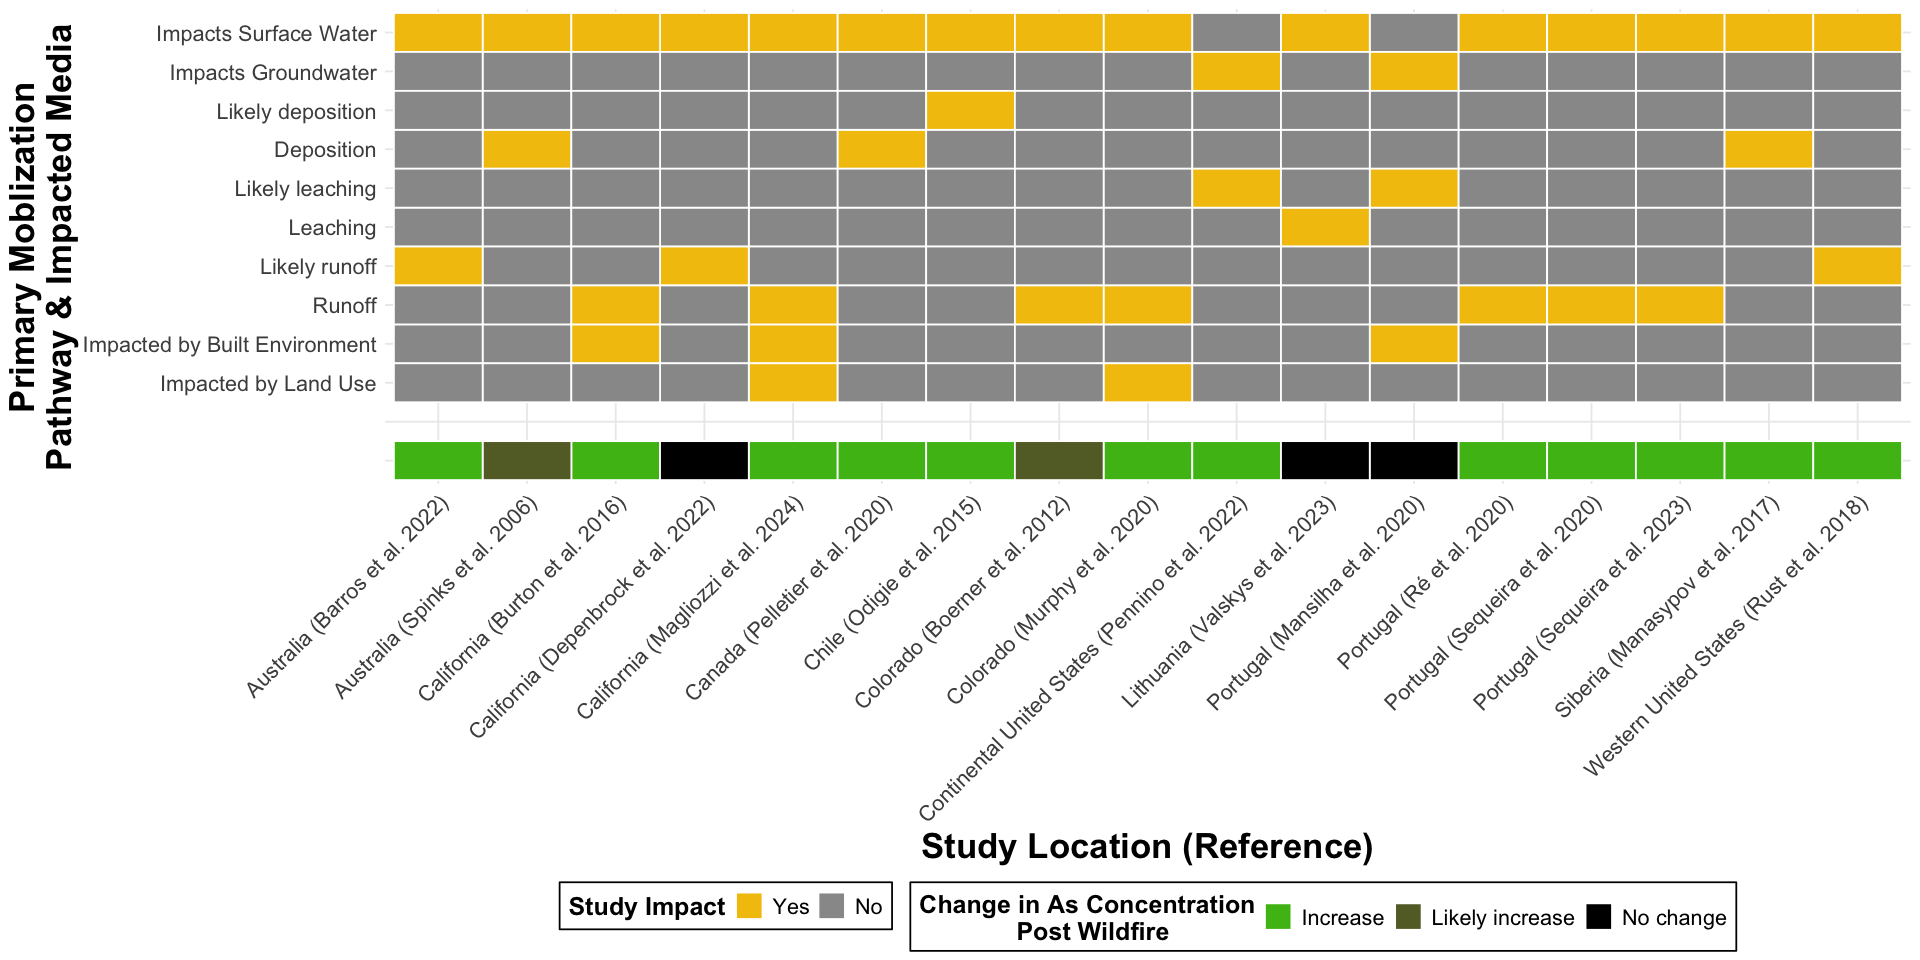

In [5]:
options(repr.plot.width=16, repr.plot.height=8) #changing size

Figure3 = ggplot() +

  # Annotation Row Layer
  geom_tile(data = annotation_df, aes(x = location_citation, y = Variable, fill = Directionality),
            color = "white", linewidth = 0.5) + 
   scale_fill_manual(values = c("Increase" = "#4CBB17", "Likely increase" = "#636B2F",
                               "No change" = "black"),
                    name = 'Change in As Concentration\n              Post Wildfire') +
  
  #Clear the fill scale to start a brand new color scale 
  new_scale_fill() +

  #plotting the space
  geom_tile(data = spacer_df, aes(x = location_citation, y = Variable), fill = NA, color = NA) +

  geom_tile(data = heatmap_df, aes(x = location_citation, y = Variable, fill = Value),
            color = "white", linewidth = 0.5) +
    scale_fill_manual(values = c("Yes" = "#f3c30a", "No" = "gray60"),
                   name = "Study Impact") + 

  theme_minimal() +

  theme(axis.title = element_text(face = "bold", size = rel(1.9)),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 13), 
    legend.title = element_text(face = "bold", size = 15),
    legend.text = element_text(size = 13), #changes legend text
    legend.position = "bottom",
    legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid')) +

  # removing labels from y axis
  scale_y_discrete(labels = function(x) ifelse(x %in% c("Spacer", "Direction"), "", x)) + 

  labs(y = "Primary Moblization\nPathway & Impacted Media", x = "Study Location (Reference)") 
                   
Figure3

In [6]:
# # exporting figure
# ggsave(Figure3, 
#        filename = 'Figure3.pdf',
#        path = Output,
#        width = 15, height = 7)